# Modelos finales · TFM Energía UCM

Entrena **una arquitectura por familia** sobre la matriz ganadora, con varias semillas, y
las deja guardadas con todo lo que hace falta para volver a usarlas.

## Por qué no vale ninguno de los notebooks anteriores

`modelo_rnn_deeplearning`, `v2_temario` y `v3_sin_series_clasicas` entrenan 15-18 modelos,
miran el resultado en pantalla y **los tiran al terminar**. Nunca se guardó ninguno. Sirven
para el relato —aquí probamos esto, salió así— no para entregar:

| | notebooks v1/v2/v3 | este |
|---|---|---|
| semillas | una | **tres**, con media ± desviación |
| guarda el `.keras` | no | **sí** |
| guarda el preprocesado | no | **sí** |
| modelos | 15-18, muchos ya descartados | **8**, uno por familia |

Y los tres entrenan los **mismos** 15 modelos: v2 añade la escalera del temario y Hyperband,
v3 quita las series clásicas. Nada de eso cambia cuál es el mejor — la escalera se queda en
13,19 frente a los 12,28 del GRU.

## Qué es una familia

Variantes de un mismo esqueleto no son familias distintas. `Seq2Seq residuo`, `+ pesos`,
`+ fine-tuning` y las seis del temario son el mismo encoder-decoder entrenado de otra
manera. Meterlas todas en un ensemble le daba a esa familia el **62 % del voto** y al GRU
—el mejor modelo individual— un 6 %. Un ensemble promedia errores *no correlacionados*:
diez copias casi idénticas no cancelan nada.

Y ojo con los nombres, porque mezclan **dos ejes distintos**:

- **la celda** — `SimpleRNN`, `LSTM`, `GRU` — qué tipo de memoria tiene la neurona
- **la topología** — directa o encoder-decoder — cómo se cablea la red

Un seq2seq no es un tipo de LSTM: es una forma de conectar, y puede estar hecho de
LSTM o de GRU indistintamente. Como `gru` nombra una celda y `seq2seq` una topología,
la lista de abajo se lee mejor con las dos columnas separadas:

| familia | topología | celda | qué aísla frente a `seq2seq` |
|---|---|---|---|
| `seq2seq` | enc-decoder | LSTM | — es la referencia |
| `gru` | enc-decoder | GRU | **la celda** |
| `simplernn` | enc-decoder | SimpleRNN | la celda, escalón básico (~35 k par.) |
| `lstm` | **directa** | LSTM | **el decoder** |
| `seq2seq_absoluto` | enc-decoder | LSTM | **el objetivo**: precio, no residuo |
| `conv1d_lstm` | enc-decoder | LSTM | convolución con stride en la entrada |
| `denso` | vista aplanada | — | control sin recurrencia |
| `boosting` | vista aplanada | — | LightGBM, un modelo por hora |

Las tres comparaciones del centro mueven **una sola cosa** cada una respecto a la
referencia. En una primera versión `lstm` no tenía rama propia y acababa construyendo
el mismo encoder-decoder que `seq2seq` —259.681 parámetros idénticos, r = 0,99947 entre
sus predicciones— así que la ablación del decoder no existía y el ensemble le daba doble
voto a esa arquitectura. Ahora `lstm` es directa: encoder, estáticos, y una `Dense` que
saca las 24 horas de golpe.

El último entra **pese a perder en MAE**, porque es de los que mejor captura el spread. La
correlación entre MAE y captura es −0,285: son métricas casi independientes, y para operar
una batería manda la segunda. Elegir campeón solo por MAE elige mal para el capítulo 7.

## Aviso · estos resultados son POSTERIORES al arreglo de la fuga (30-ago-2026)

Hasta esa fecha el encoder recibía **las 24 horas de generación observada del día D** para
predecir D+1. A las 11:00 de D esa generación no existe: medido ese mismo día, `esios_gen` y
`entsoe_gen_data` tenían cero horas del día en curso.

El fallo estaba en `preparar_tensores.py`, no en la matriz. El panel de `cols_dm1` se montaba
con `desfase=2`, y eso hacía que la última posición de la ventana cayera en el día D en lugar
de en D−1. Un desajuste de una posición al reensamblar la secuencia desde la matriz.

Medido antes y después sobre `wind_mw`, con el objetivo 2026-08-30:

| | última posición del encoder | ¿publicada a las 11:00 de D? |
|---|---|---|
| antes (`desfase=2`) | día D | **no**, está ocurriendo |
| ahora (`desfase=1`) | día D−1 | sí |

Los otros dos bloques no se tocan y son legítimos: el **precio** del día D se casó a las 13:00
de D−1, y el **programado** (`_D`, el PBF) se publica a las 14:00 de D−1.

**Los números empeoran respecto a la ejecución anterior, y eso es lo correcto**: se ha
quitado información que el modelo no podía tener. La tabla previa está guardada en
`data/gold/finales_nucleo_ANTES_del_arreglo/`, y la diferencia entre ambas es un resultado en
sí mismo — cuánto valía la fuga en €/MWh.

De propina, el mismo cambio recupera un día: con `desfase=2` el panel dejaba dos días vacíos
al final y la ventana del último los pisaba. Ahora deja uno.

## 0 · ¿Está usando la GPU?

Conviene comprobarlo **antes** de lanzar los ~40 minutos de entrenamiento. Que TensorFlow
*vea* la tarjeta no garantiza que la use: si falta una librería de CUDA, cae a CPU en
silencio y solo lo notas por lo lento que va.

Las tres comprobaciones de abajo, de menos a más concluyente:

1. **la ve** — `list_physical_devices` devuelve algo
2. **coloca operaciones en ella** — una multiplicación que informa dónde se ejecutó
3. **es más rápida que la CPU** — la única que descarta que esté cayendo a CPU sin avisar

In [1]:
import tensorflow as tf, time, numpy as np

gpus = tf.config.list_physical_devices("GPU")
print(f"1. dispositivos GPU visibles: {len(gpus)}")
for g in gpus:
    det = tf.config.experimental.get_device_details(g)
    print(f"     {g.name} · {det.get('device_name', '?')} · "
          f"compute capability {det.get('compute_capability', '?')}")

if not gpus:
    print()
    print("   NO HAY GPU. Vas a entrenar por CPU: cuenta horas en lugar de minutos.")
    print("   Si estas en VS Code, revisa que el kernel sea el de WSL y no el de Windows")
    print("   -- TensorFlow >= 2.11 no usa CUDA en Windows nativo.")
else:
    # 2. ¿coloca las operaciones ahi de verdad?
    tf.debugging.set_log_device_placement(False)
    with tf.device("/GPU:0"):
        a = tf.random.normal((2000, 2000))
        _ = tf.matmul(a, a)
    print(f"\n2. una matmul de 2000x2000 se coloco en: {a.device.split('/')[-1]}")

    # 3. la prueba que de verdad descarta que este cayendo a CPU en silencio
    def cronometrar(dispositivo, n=3):
        with tf.device(dispositivo):
            x = tf.random.normal((4000, 4000))
            tf.matmul(x, x).numpy()                 # calienta, no cuenta
            t = time.perf_counter()
            for _ in range(n):
                tf.matmul(x, x).numpy()
            return (time.perf_counter() - t) / n

    t_gpu = cronometrar("/GPU:0")
    t_cpu = cronometrar("/CPU:0")
    print(f"\n3. matmul 4000x4000:  GPU {t_gpu*1000:7.1f} ms  ·  CPU {t_cpu*1000:7.1f} ms"
          f"  ->  x{t_cpu/t_gpu:.0f}")
    if t_cpu / t_gpu < 2:
        print("   SOSPECHOSO: la GPU deberia ir bastante mas rapido que eso. Puede que")
        print("   este cayendo a CPU sin avisar.")
    else:
        print("   La GPU esta trabajando.")

    memoria = tf.config.experimental.get_memory_info("GPU:0")
    print(f"\n   memoria en uso ahora: {memoria['current']/2**20:,.0f} MB "
          f"(pico {memoria['peak']/2**20:,.0f} MB)")
    print("   Con `nvidia-smi -l 2` en otra terminal lo ves en vivo mientras entrena:")
    print("   la columna GPU-Util deberia moverse entre el 30 % y el 90 %.")

1. dispositivos GPU visibles: 0

   NO HAY GPU. Vas a entrenar por CPU: cuenta horas en lugar de minutos.
   Si estas en VS Code, revisa que el kernel sea el de WSL y no el de Windows
   -- TensorFlow >= 2.11 no usa CUDA en Windows nativo.


In [2]:
import sys, time, json
from pathlib import Path

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "gold").is_dir())
sys.path.append(str(REPO / "scripts"))

MATRIZ   = "nucleo"          # la ganadora de la comparación del notebook 05
SEMILLAS = 3
FAMILIAS = ["gru", "conv1d_lstm", "seq2seq", "simplernn", "lstm", "denso",
            "boosting", "seq2seq_absoluto"]

EJECUTAR = True             # <- ponlo a True y ejecuta esta celda

SALIDA = REPO / "data" / "gold" / f"finales_{MATRIZ}"
print(f"matriz {MATRIZ} · {len(FAMILIAS)} familias x {SEMILLAS} semillas = "
      f"{len(FAMILIAS) * SEMILLAS} entrenamientos")
print(f"salida: {SALIDA}")

matriz nucleo · 8 familias x 3 semillas = 24 entrenamientos
salida: D:\POSGRADO\TFM\edev_models\data\gold\finales_nucleo


## 1 · Entrenar

Cada entrenamiento escribe en `por_semilla.csv`, así que se puede parar y continuar: al
relanzar salta los que ya estén.

Con `guardar=True` cada familia deja su `.keras` **y** su `.preprocesado.json`. Lo segundo
no es opcional: un `.keras` guarda pesos, no la estandarización ni el orden de columnas.
Cargarlo sin eso devuelve números plausibles y equivocados, sin ningún aviso — el modelo
aprendió que el canal 17 es la eólica programada, y si la matriz se regenera con otro orden
sigue prediciendo tan tranquilo.

In [3]:
GUARDAR = True

if not EJECUTAR:
    print("EJECUTAR = False. Cambia a True en la celda anterior.")
    print("Si ya lo lanzaste por terminal, salta a la sección 2: lee los mismos ficheros.")
else:
    import numpy as np, pandas as pd
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    from preparar_tensores import preparar, residuo
    import entrenar_finales as EF

    print("GPU:", bool(tf.config.list_physical_devices("GPU")))
    SALIDA.mkdir(parents=True, exist_ok=True)

    T = preparar(MATRIZ)
    yr, inv_r, mu_r, sd_r = residuo(T)
    mu_y, sd_y = float(T.y[T.tr].mean()), float(T.y[T.tr].std())
    ys = ((T.y - mu_y) / sd_y).astype("float32")
    inv_abs = lambda p, m: p * sd_y + mu_y

    nv = EF.metricas(T.y[T.va], T.naive[T.va])
    nt = EF.metricas(T.y[T.te], T.naive[T.te])
    print(f"   naive: val {nv['MAE']:.2f} · test {nt['MAE']:.2f} "
          f"· captura val {nv['captura_%']:.1f}%")
    print()

    csv = SALIDA / "por_semilla.csv"
    filas = pd.read_csv(csv).to_dict("records") if csv.exists() else []
    yahay = {(r["familia"], r["semilla"]) for r in filas}
    t0 = time.time()
    for fam in FAMILIAS:
        for s in range(SEMILLAS):
            if (fam, EF.SEMILLA + s) in yahay:
                continue
            pv, pt, npar, modelo = EF.entrenar(fam, T, yr, inv_r, ys, inv_abs,
                                               EF.SEMILLA + s, keras, layers)
            mv, mt = EF.metricas(T.y[T.va], pv), EF.metricas(T.y[T.te], pt)
            filas.append({"familia": fam, "semilla": EF.SEMILLA + s, "parametros": npar,
                          "MAE_val": round(mv["MAE"], 3), "MAE_test": round(mt["MAE"], 3),
                          "captura_val_%": round(mv["captura_%"], 2),
                          "captura_test_%": round(mt["captura_%"], 2),
                          "pico_1h_test_%": round(mt["pico_1h_%"], 2),
                          "vs_naive_val_%": round(100 * (mv["MAE"] / nv["MAE"] - 1), 1)})
            pd.DataFrame(filas).to_csv(csv, index=False)
            _cols = [f"h{h:02d}" for h in range(24)]
            pd.DataFrame(pv, index=pd.to_datetime(T.fechas[T.va]),
                         columns=_cols).to_csv(SALIDA / f"pred_val_{fam}__s{s}.csv")
            # Tambien las de test: sin ellas la seccion 3 no puede calcular el MAE
            # del ensemble y se quedaba en la matriz de correlaciones.
            pd.DataFrame(pt, index=pd.to_datetime(T.fechas[T.te]),
                         columns=_cols).to_csv(SALIDA / f"pred_test_{fam}__s{s}.csv")
            print(f"   {fam:18s} s{s}  MAE val {mv['MAE']:6.3f} · test {mt['MAE']:6.3f} "
                  f"· captura {mt['captura_%']:5.1f}%   [{(time.time()-t0)/60:.0f} min]")

            # TODAS las semillas, no solo la primera. El representante de cada familia
            # se elige despues por MAE de VALIDACION, y puede ser la s1 o la s2: guardar
            # solo la s0 exportaria un modelo distinto del que la tabla declara mejor.
            # Ocupan medio mega cada uno, asi que no hay razon para elegir antes de saber.
            if GUARDAR and modelo is not None:
                modelo.save(SALIDA / f"{fam}__s{s}.keras")
                pre = T.preprocesado()   # mismo para las 3 semillas
                pre["familia"] = fam
                pre["objetivo"] = "absoluto" if fam == "seq2seq_absoluto" else "residuo"
                pre["destipificar"] = ({"mu": mu_y, "sd": sd_y, "nota": "y = pred*sd + mu"}
                                       if fam == "seq2seq_absoluto"
                                       else {"mu": mu_r, "sd": sd_r,
                                             "nota": "y = pred*sd + mu + naive(dia D)"})
                pre["entrada"] = "plana" if fam in ("denso", "boosting") else "tensores"
                (SALIDA / f"{fam}.preprocesado.json").write_text(
                    json.dumps(pre, indent=2, ensure_ascii=False), encoding="utf-8")

    (SALIDA / "meta.json").write_text(json.dumps({
        "matriz": MATRIZ, "hash": T.meta.get("hash"), "semillas": SEMILLAS,
        "naive_val_MAE": round(nv["MAE"], 3), "naive_test_MAE": round(nt["MAE"], 3),
        "dias_train": int(T.tr.sum()), "dias_val": int(T.va.sum()),
        "dias_test": int(T.te.sum())}, indent=2), encoding="utf-8")
    print()
    print(f"Listo. {len(filas)} entrenamientos en {SALIDA}")

GPU: False


nucleo    hash 4a8f328e · 2,389 dias · encoder 51 canales · decoder 22 · estaticos 29 · train 1812 val 365 test 212
   naive: val 19.95 · test 16.71 · captura val 81.7%


Listo. 24 entrenamientos en D:\POSGRADO\TFM\edev_models\data\gold\finales_nucleo


### 1.1 · Recuperar las predicciones de test que faltan

Las ejecuciones anteriores solo guardaban `pred_val_*`. Sin las de test no hay MAE de
ensemble que calcular.

No hace falta reentrenar: los `.keras` están guardados, así que es **inferencia pura** y
tarda segundos. Solo `boosting` no tiene modelo en disco —LightGBM no se serializa aquí— y
esa familia hay que reentrenarla.

In [4]:
import numpy as np, pandas as pd
from tensorflow import keras as K
from preparar_tensores import preparar, residuo
from entrenar_finales import vista_plana

if "T" not in globals():
    T = preparar(MATRIZ)
_yr, inv_r, _, _ = residuo(T)
mu_y, sd_y = float(T.y[T.tr].mean()), float(T.y[T.tr].std())
cols = [f"h{h:02d}" for h in range(24)]
fechas_te = pd.to_datetime(T.fechas[T.te])

hechos = pd.read_csv(SALIDA / "por_semilla.csv")
recuperadas, sin_modelo = [], []
for r in hechos.itertuples():
    s = r.semilla - 42
    if (SALIDA / f"pred_test_{r.familia}__s{s}.csv").exists():
        continue
    # boosting no es un .keras sino una carpeta con 24 ficheros nativos de LightGBM
    if r.familia == "boosting":
        from entrenar_finales import BosqueHorario
        carpeta = SALIDA / f"{r.familia}__s{s}"
        if not carpeta.is_dir():
            sin_modelo.append(f"{r.familia}__s{s}")
            continue
        m = BosqueHorario.cargar(carpeta)
    else:
        mk = SALIDA / f"{r.familia}__s{s}.keras"
        if not mk.exists():
            sin_modelo.append(f"{r.familia}__s{s}")
            continue
        m = K.models.load_model(mk)
    X = vista_plana(T)[T.te] if r.familia in ("denso", "boosting") else T.ent(T.te)
    p = m.predict(X, verbose=0)
    # destipificar por el mismo camino que uso el entrenamiento
    p = (p * sd_y + mu_y) if r.familia == "seq2seq_absoluto" else inv_r(p, T.te)
    pd.DataFrame(p, index=fechas_te, columns=cols).to_csv(
        SALIDA / f"pred_test_{r.familia}__s{s}.csv")
    recuperadas.append(f"{r.familia}__s{s}")

print(f"{len(recuperadas)} predicciones de test recuperadas por inferencia")
if sin_modelo:
    print(f"sin .keras, hay que reentrenar: {sin_modelo}")

0 predicciones de test recuperadas por inferencia


## 2 · Resultados por familia

Media y desviación sobre las semillas. **La desviación es la que dice si una diferencia
significa algo**: dos ejecuciones idénticas difieren hasta 0,58 en MAE, así que por debajo
de eso no se decide nada.

In [5]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

csv = SALIDA / "por_semilla.csv"
if not csv.exists():
    print(f"Todavía no hay resultados en {csv}.")
    print("Ejecuta la sección 1, o lánzalo por terminal:")
    print(f"   python scripts/entrenar_finales.py --matriz {MATRIZ} "
          f"--semillas {SEMILLAS} --guardar-modelos")
    f = None
else:
    f = pd.read_csv(csv)
    meta = json.loads((SALIDA / "meta.json").read_text()) if (SALIDA / "meta.json").exists() else {}
    naive_te = meta.get("naive_test_MAE", np.nan)
    res = (f.groupby("familia").agg(
        n=("semilla", "size"), parametros=("parametros", "first"),
        MAE_val=("MAE_val", "mean"), sd_val=("MAE_val", "std"),
        MAE_test=("MAE_test", "mean"), sd_test=("MAE_test", "std"),
        captura_test=("captura_test_%", "mean"),
        pico_1h=("pico_1h_test_%", "mean")).round(3).sort_values("MAE_val"))
    res["vs_naive_%"] = (100 * (res.MAE_test / naive_te - 1)).round(1)
    # Positivo = el modelo generaliza PEOR de lo que prometia en validacion. Es la
    # columna que separa a los que se ajustaron al periodo de seleccion de los que
    # aprendieron algo que aguanta en 2026.  val = 2025 entero, test = ene-jul 2026.
    res["salto"] = (res.MAE_test - res.MAE_val).round(3)
    display(res)
    peor = res.salto.idxmax()
    if res.salto.max() > 1:
        print(f"OJO: {peor} empeora {res.salto.max():+.2f} al pasar a test. "
              f"Su puesto en validación no dice nada de cómo predice 2026.")
    print(f"naive de test: {naive_te} €/MWh")
    print(f"{len(f)} de {len(FAMILIAS) * SEMILLAS} entrenamientos")

HAY = f is not None and len(f) > 0

,n,parametros,MAE_val,sd_val,MAE_test,sd_test,captura_test,pico_1h,vs_naive_%,salto
familia,,,,,,,,,,
denso,3,566040,12.794,0.102,15.388,0.814,89.740,76.573,-7.9,2.594
boosting,3,10509,13.288,0.025,13.852,0.105,88.633,77.517,-17.1,0.564
lstm,3,322712,13.462,0.293,15.996,0.257,89.057,73.897,-4.3,2.534
gru,3,196129,13.589,0.178,12.860,0.264,89.963,77.360,-23.1,-0.729
seq2seq,3,259681,13.851,0.134,12.911,0.103,89.727,73.270,-22.8,-0.940
conv1d_lstm,3,286305,14.159,0.272,13.402,0.335,89.770,77.043,-19.8,-0.757
simplernn,3,34689,14.618,0.188,13.805,0.647,89.560,73.897,-17.4,-0.813
seq2seq_absoluto,3,259681,15.263,0.328,15.407,0.644,93.020,84.590,-7.8,0.144


OJO: denso empeora +2.59 al pasar a test. Su puesto en validación no dice nada de cómo predice 2026.
naive de test: 16.714 €/MWh
24 de 24 entrenamientos


## 3 · El ensemble

Un representante por familia, **el mejor según validación**. El test no interviene en
ninguna decisión.

El anterior elegía miembros mirando el test y promediaba dieciséis modelos de los que diez
eran el mismo encoder-decoder. Este promedia familias de verdad distintas, que es lo que
hace que un ensemble funcione.

In [6]:
if not HAY:
    print("Sin resultados todavía.")
else:
    mejor = f.loc[f.groupby("familia")["MAE_val"].idxmin()]
    print("Representante de cada familia (elegido por MAE de VALIDACIÓN):")
    display(mejor[["familia", "semilla", "MAE_val", "MAE_test", "captura_test_%"]]
            .sort_values("MAE_val").round(3))

    pv = {}
    for r in mejor.itertuples():
        p = SALIDA / f"pred_val_{r.familia}__s{r.semilla - 42}.csv"
        if p.exists():
            pv[r.familia] = pd.read_csv(p, index_col=0).values.ravel()

    if len(pv) > 1:
        print()
        print("Cuánto se parecen entre sí las predicciones de cada familia:")
        # Un ensemble gana promediando modelos que se equivocan en sitios DISTINTOS. Si dos
        # familias correlacionan a 0,99, promediarlas no cancela nada: es tener el mismo
        # modelo dos veces. Aqui se ve cuales aportan diversidad de verdad.
        c = pd.DataFrame({a: {b: np.corrcoef(x, y)[0, 1] for b, y in pv.items()}
                          for a, x in pv.items()}).round(3)
        display(c)
        import itertools
        pares = [(a, b, c.loc[a, b]) for a, b in itertools.combinations(c.index, 2)]
        pares.sort(key=lambda x: x[2])
        print(f"el par MENOS parecido : {pares[0][0]} / {pares[0][1]}  r={pares[0][2]:.3f}"
              f"   <- el que mas aporta al promedio")
        print(f"el par MAS parecido   : {pares[-1][0]} / {pares[-1][1]}  r={pares[-1][2]:.3f}")
        if pares[-1][2] > 0.98:
            print()
            print("Ese ultimo par esta por encima de 0,98: son practicamente el mismo")
            print("modelo y meter los dos en el ensemble le da doble voto a esa forma de")
            print("equivocarse.")

Representante de cada familia (elegido por MAE de VALIDACIÓN):


,familia,semilla,MAE_val,MAE_test,captura_test_%
17,denso,44,12.679,14.485,89.79
14,lstm,44,13.170,15.942,90.01
19,boosting,43,13.264,13.837,88.92
2,gru,44,13.447,13.108,89.73
8,seq2seq,44,13.763,13.005,90.82
5,conv1d_lstm,44,13.888,13.639,89.91
10,simplernn,43,14.408,14.224,89.84
23,seq2seq_absoluto,44,14.912,16.140,93.18



Cuánto se parecen entre sí las predicciones de cada familia:


,boosting,conv1d_lstm,denso,gru,lstm,seq2seq,seq2seq_absoluto,simplernn
boosting,1.000,0.960,0.967,0.965,0.968,0.961,0.942,0.960
conv1d_lstm,0.960,1.000,0.963,0.982,0.964,0.984,0.960,0.974
denso,0.967,0.963,1.000,0.963,0.981,0.961,0.947,0.954
gru,0.965,0.982,0.963,1.000,0.967,0.989,0.957,0.981
lstm,0.968,0.964,0.981,0.967,1.000,0.965,0.949,0.962
seq2seq,0.961,0.984,0.961,0.989,0.965,1.000,0.959,0.976
seq2seq_absoluto,0.942,0.960,0.947,0.957,0.949,0.959,1.000,0.955
simplernn,0.960,0.974,0.954,0.981,0.962,0.976,0.955,1.000


el par MENOS parecido : boosting / seq2seq_absoluto  r=0.942   <- el que mas aporta al promedio
el par MAS parecido   : gru / seq2seq  r=0.989

Ese ultimo par esta por encima de 0,98: son practicamente el mismo
modelo y meter los dos en el ensemble le da doble voto a esa forma de
equivocarse.


In [7]:
if not HAY:
    print("Sin resultados todavía.")
else:
    import entrenar_finales as EF
    from preparar_tensores import preparar
    if "T" not in globals():
        T = preparar(MATRIZ)
    cols = [f"h{h:02d}" for h in range(24)]

    def leer(tag, fam, s):
        p = SALIDA / f"pred_{tag}_{fam}__s{s}.csv"
        return pd.read_csv(p, index_col=0).values if p.exists() else None

    naive_val = EF.metricas(T.y[T.va], T.naive[T.va])["MAE"]
    mejor = f.loc[f.groupby("familia")["MAE_val"].idxmin()]

    miembros, fuera = [], []
    for r in mejor.itertuples():
        s = r.semilla - 42
        v, t = leer("val", r.familia, s), leer("test", r.familia, s)
        if v is None or t is None:
            fuera.append((r.familia, "faltan predicciones -- ejecuta la seccion 1.1"))
        elif r.MAE_val >= naive_val:
            # Un miembro peor que la persistencia arrastra el promedio hacia abajo.
            fuera.append((r.familia, f"no bate al naive en val ({r.MAE_val:.2f})"))
        else:
            miembros.append((r.familia, s, v, t))

    if len(miembros) < 2:
        print("Menos de dos miembros válidos: no hay ensemble.")
    else:
        e_va = np.mean([m[2] for m in miembros], axis=0)
        e_te = np.mean([m[3] for m in miembros], axis=0)
        ev, et = EF.metricas(T.y[T.va], e_va), EF.metricas(T.y[T.te], e_te)
        ind = res.MAE_test.idxmin()

        print(f"Ensemble de {len(miembros)} familias, elegidas por VALIDACIÓN:")
        print(f"   {', '.join(m[0] for m in miembros)}")
        print()
        print(f"   val   MAE {ev['MAE']:6.3f}")
        print(f"   test  MAE {et['MAE']:6.3f} · captura {et['captura_%']:5.1f}% "
              f"· pico1h {et['pico_1h_%']:5.1f}%")
        print()
        d = et["MAE"] - res.loc[ind, "MAE_test"]
        print(f"   mejor familia individual en test: {ind} "
              f"{res.loc[ind, 'MAE_test']:.3f}")
        print(f"   el ensemble {'GANA' if d < 0 else 'PIERDE'} por {abs(d):.3f} €/MWh")
        if d >= 0:
            print("   Promediar no siempre suma: si una familia domina y las demás")
            print("   se equivocan parecido, el promedio la empeora.")

        # LA TABLA PARA LA MEMORIA. La de la seccion 2 sale de por_semilla.csv, que solo
        # tiene familias: el ensemble no cabia ahi y quedaba suelto en este print, con lo
        # que el mejor resultado del trabajo no aparecia en ningun cuadro. Aqui si, y
        # ordenada por TEST, que es el criterio con el que se juzga.
        naive_te = meta.get("naive_test_MAE", np.nan)
        tabla = res.copy()
        tabla.loc["ENSEMBLE"] = {
            "n": len(miembros), "parametros": int(res.parametros.sum()),
            "MAE_val": round(ev["MAE"], 3), "sd_val": np.nan,
            "MAE_test": round(et["MAE"], 3), "sd_test": np.nan,
            "captura_test": round(et["captura_%"], 3),
            "pico_1h": round(et["pico_1h_%"], 3),
            "vs_naive_%": round(100 * (et["MAE"] / naive_te - 1), 1),
            "salto": round(et["MAE"] - ev["MAE"], 3)}
        tabla.loc["naive (persistencia)"] = {
            "n": np.nan, "parametros": 0,
            "MAE_val": round(naive_val, 3), "sd_val": np.nan,
            "MAE_test": round(naive_te, 3), "sd_test": np.nan,
            "captura_test": round(EF.metricas(T.y[T.te], T.naive[T.te])["captura_%"], 3),
            "pico_1h": round(EF.metricas(T.y[T.te], T.naive[T.te])["pico_1h_%"], 3),
            "vs_naive_%": 0.0, "salto": round(naive_te - naive_val, 3)}
        print()
        print("=" * 76)
        print("TABLA FINAL -- ordenada por MAE de TEST, que es el criterio de juicio")
        display(tabla.sort_values("MAE_test"))
        tabla.sort_values("MAE_test").to_csv(SALIDA / "tabla_final.csv")
        print(f"guardada en {SALIDA / 'tabla_final.csv'}")

        pd.DataFrame(e_va, index=pd.to_datetime(T.fechas[T.va]),
                     columns=cols).to_csv(SALIDA / "pred_val_ensemble.csv")
        pd.DataFrame(e_te, index=fechas_te if "fechas_te" in globals()
                     else pd.to_datetime(T.fechas[T.te]),
                     columns=cols).to_csv(SALIDA / "pred_test_ensemble.csv")

    for fam, por in fuera:
        print(f"   fuera: {fam:18s} {por}")

Ensemble de 8 familias, elegidas por VALIDACIÓN:
   boosting, conv1d_lstm, denso, gru, lstm, seq2seq, seq2seq_absoluto, simplernn

   val   MAE 12.196
   test  MAE 12.126 · captura  92.3% · pico1h  80.2%

   mejor familia individual en test: gru 12.860
   el ensemble GANA por 0.734 €/MWh

TABLA FINAL -- ordenada por MAE de TEST, que es el criterio de juicio


,n,parametros,MAE_val,sd_val,MAE_test,sd_test,captura_test,pico_1h,vs_naive_%,salto
familia,,,,,,,,,,
ENSEMBLE,8.0,1935746,12.196,NaN,12.126,NaN,92.301,80.189,-27.5,-0.071
gru,3.0,196129,13.589,0.178,12.860,0.264,89.963,77.360,-23.1,-0.729
seq2seq,3.0,259681,13.851,0.134,12.911,0.103,89.727,73.270,-22.8,-0.940
conv1d_lstm,3.0,286305,14.159,0.272,13.402,0.335,89.770,77.043,-19.8,-0.757
simplernn,3.0,34689,14.618,0.188,13.805,0.647,89.560,73.897,-17.4,-0.813
boosting,3.0,10509,13.288,0.025,13.852,0.105,88.633,77.517,-17.1,0.564
denso,3.0,566040,12.794,0.102,15.388,0.814,89.740,76.573,-7.9,2.594
seq2seq_absoluto,3.0,259681,15.263,0.328,15.407,0.644,93.020,84.590,-7.8,0.144
lstm,3.0,322712,13.462,0.293,15.996,0.257,89.057,73.897,-4.3,2.534


guardada en D:\POSGRADO\TFM\edev_models\data\gold\finales_nucleo\tabla_final.csv


## 4 · MAE contra captura — no son lo mismo

El campeón por error y el campeón por dinero **no tienen por qué coincidir**, y en la
ejecución anterior no coincidían: el modelo con mejor captura del spread era el segundo peor
en MAE.

Para operar una batería no importa clavar 47,3 €/MWh: importa acertar **cuándo** cargar y
cuándo descargar. Si los dos campeones difieren, van los dos a la memoria.

mejor MAE     : gru                  12.86 €/MWh · captura 90.0%
mejor captura : seq2seq_absoluto     15.41 €/MWh · captura 93.0%

NO coinciden. Exportar los dos y decirlo en la memoria: es el Hallazgo 1
del informe de fases confirmado desde el lado del deep learning.


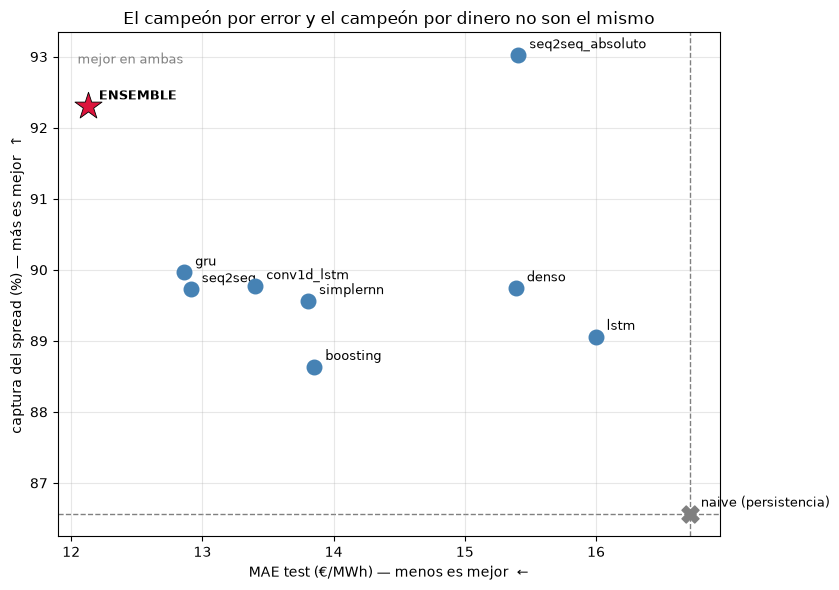

grafico guardado en D:\POSGRADO\TFM\edev_models\data\gold\finales_nucleo\mae_vs_captura.png


In [8]:
if not HAY:
    print("Sin resultados todavía.")
else:
    # res viene ordenada por MAE_val, asi que res.index[0] es el mejor en VALIDACION.
    # Llamarlo "mejor MAE" corona al que mejor se ajusto al periodo de seleccion, no al
    # que mejor predice 2025 -- justo el error que esta seccion quiere evitar.
    top_mae = res.MAE_test.idxmin()
    top_cap = res.captura_test.idxmax()
    print(f"mejor MAE     : {top_mae:20s} {res.loc[top_mae,'MAE_test']:.2f} €/MWh · "
          f"captura {res.loc[top_mae,'captura_test']:.1f}%")
    print(f"mejor captura : {top_cap:20s} {res.loc[top_cap,'MAE_test']:.2f} €/MWh · "
          f"captura {res.loc[top_cap,'captura_test']:.1f}%")
    print()
    if top_mae != top_cap:
        print("NO coinciden. Exportar los dos y decirlo en la memoria: es el Hallazgo 1")
        print("del informe de fases confirmado desde el lado del deep learning.")
    else:
        print("Coinciden en esta ejecución. Aun así conviene reportar las dos métricas:")
        print("la correlación entre ambas es -0,285, así que la coincidencia es suerte.")

    # Si la seccion 3 ya corrio, `tabla` trae ademas el ENSEMBLE y el naive. Dibujar
    # solo las familias dejaba fuera del grafico el mejor resultado del trabajo y el
    # liston contra el que se mide todo.
    G = tabla if "tabla" in globals() else res

    fig, ax = plt.subplots(figsize=(8.5, 6))
    nv_mae = G.loc["naive (persistencia)", "MAE_test"] if "naive (persistencia)" in G.index else None
    nv_cap = G.loc["naive (persistencia)", "captura_test"] if nv_mae is not None else None

    if nv_mae is not None:
        # las dos rectas parten el plano en cuadrantes: arriba-izquierda es "mejor que la
        # persistencia en las DOS metricas", que es lo unico que cuenta como ganar.
        ax.axvline(nv_mae, color="grey", ls="--", lw=1, zorder=0)
        ax.axhline(nv_cap, color="grey", ls="--", lw=1, zorder=0)
        ax.annotate("mejor en ambas", (0.03, 0.96), xycoords="axes fraction",
                    fontsize=9, color="grey", va="top")

    for nom, r in G.iterrows():
        if nom == "ENSEMBLE":
            ax.scatter(r.MAE_test, r.captura_test, s=420, marker="*",
                       color="crimson", zorder=5, edgecolor="black", linewidth=.6)
            peso = "bold"
        elif nom == "naive (persistencia)":
            ax.scatter(r.MAE_test, r.captura_test, s=150, marker="X",
                       color="grey", zorder=4)
            peso = "normal"
        else:
            ax.scatter(r.MAE_test, r.captura_test, s=110, color="steelblue", zorder=3)
            peso = "normal"
        ax.annotate(nom, (r.MAE_test, r.captura_test), xytext=(8, 5),
                    textcoords="offset points", fontsize=9, fontweight=peso)

    ax.set_xlabel("MAE test (€/MWh) — menos es mejor  ←")
    ax.set_ylabel("captura del spread (%) — más es mejor  ↑")
    ax.set_title("El campeón por error y el campeón por dinero no son el mismo")
    ax.grid(alpha=.3); plt.tight_layout()
    plt.savefig(SALIDA / "mae_vs_captura.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"grafico guardado en {SALIDA / 'mae_vs_captura.png'}")

## 5 · Qué queda guardado

Lo que hay en `data/gold/finales_<matriz>/` y para qué sirve cada cosa.

In [9]:
if not SALIDA.exists():
    print("Todavía no se ha ejecutado nada.")
else:
    for p in sorted(SALIDA.iterdir()):
        kb = p.stat().st_size / 1024
        que = {".keras": "el modelo",
               ".json": "preprocesado: escaladores y orden de columnas"}.get(p.suffix, "")
        if p.name == "meta.json":
            que = "matriz, hash y listones del naive"
        elif p.name == "por_semilla.csv":
            que = "una fila por entrenamiento"
        elif p.name.startswith("pred_val_"):
            que = "predicciones de validación, 365 días x 24 h"
        elif p.name.startswith("pred_test_"):
            que = "predicciones de test, 211 días x 24 h"
        elif p.name.endswith(".bak"):
            que = "copia previa al reentrenamiento de lstm/boosting/simplernn s0"
        print(f"  {kb:9,.0f} KB  {p.name:38s} {que}")
    print()
    print("Cada .keras necesita su .preprocesado.json para poder usarse. Al cargarlo hay")
    print("que comprobar que `hash_matriz` coincide con el de la matriz del día: si no,")
    print("fallar en voz alta -- un modelo con las columnas cambiadas de sitio sigue")
    print("prediciendo, y nadie se entera.")

          9 KB  boosting.preprocesado.json             preprocesado: escaladores y orden de columnas
          4 KB  boosting__s0                           
          4 KB  boosting__s1                           
          4 KB  boosting__s2                           
          9 KB  conv1d_lstm.preprocesado.json          preprocesado: escaladores y orden de columnas
      3,431 KB  conv1d_lstm__s0.keras                  el modelo
      3,431 KB  conv1d_lstm__s1.keras                  el modelo
      3,431 KB  conv1d_lstm__s2.keras                  el modelo
          9 KB  denso.preprocesado.json                preprocesado: escaladores y orden de columnas
      6,663 KB  denso__s0.keras                        el modelo
      6,663 KB  denso__s1.keras                        el modelo
      6,663 KB  denso__s2.keras                        el modelo
          9 KB  gru.preprocesado.json                  preprocesado: escaladores y orden de columnas
      2,365 KB  gru__s0.keras         

## 6 · LightGBM, aparte del arnés compartido

`boosting` arriba es un LightGBM entrenado con este mismo arnés: vista aplanada del encoder,
24 modelos por hora, sin afinar. Aparte de eso hay otro camino, con matriz nucleo directa (sin
resumir a tensores) y afinamiento propio -- por eso vive en scripts sueltos y no en
`entrenar_finales.py`. Las secciones siguientes son ese camino, de principio a fin.

### 6.1 · Afinamiento (Optuna, `afinamiento_lightgbm_horario.py`)

300 trials sobre la matriz horaria propia. Mismo espacio de búsqueda que la versión diaria,
sin `MultiOutputRegressor` porque aquí hay una sola columna de salida, no 24.

In [10]:
import optuna
from lightgbm import LGBMRegressor

def construir_modelo(trial: optuna.Trial) -> LGBMRegressor:
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 2000, step=50),
        "num_leaves": trial.suggest_int("num_leaves", 8, 256, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 14),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample_freq": 1, "random_state": 42, "n_jobs": -1, "verbosity": -1,
    }
    return LGBMRegressor(**params)


study = optuna.load_study(study_name=None, storage=f"sqlite:///{REPO / 'data_temp' / 'afinamiento_lightgbm_horario.db'}")
print(f"trials: {len(study.trials)}  ·  mejor MAE: {study.best_value:.3f}")
for k, v in study.best_params.items():
    print(f"  {k} = {v}")

D:\POSGRADO\TFM\edev_models\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[I 2026-09-07 21:06:40,250] Study name was omitted but trying to load 'lightgbm_horario_precio' because that was the only study found in the storage.


trials: 300  ·  mejor MAE: 12.547
  n_estimators = 1900
  num_leaves = 27
  max_depth = 10
  learning_rate = 0.017265119138779546
  subsample = 0.597032055679207
  colsample_bytree = 0.7696132252880693
  reg_alpha = 0.0010694942634823176
  reg_lambda = 0.0228121782480138
  min_child_samples = 8


### 6.2 · Entrenado sobre `nucleo` (`modelo_lightgbm_nucleo.py`)

Un solo modelo para las 24 horas (hora como feature), no 24 por separado. Reutiliza los
hiperparámetros de 6.1, ya afinados sobre la matriz propia -- sin volver a afinar sobre nucleo,
por tiempo. MAE de referencia sobre nuestra propia matriz: 12,86.

In [11]:
import joblib
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_parquet(REPO / "data" / "gold" / "matriz_nucleo.parquet")
COLS_OBJETIVO = "target_price"
COLS_CONTROL = ["fecha_pred", "fecha_objetivo", "ts", "split", "hora"]
COLS_OTROS = ["meteo_es_forecast", "imputado_apagon", "ventana_pisa_apagon",
              "pbf_publicado_D", "pbf_completo_D"]
COLS_ARRANQUE_TARDIO = [
    "capinst_battery_hybrid_mw", "capinst_solar_pv_hybrid_mw", "capinst_wind_hybrid_mw",
    "ree_cbattery_mw_Dm1", "ree_cbattery_mw_Dm6", "ree_gbattery_mw_Dm1", "ree_gbattery_mw_Dm6",
]
excluir = set(COLS_CONTROL + COLS_OTROS + COLS_ARRANQUE_TARDIO + [COLS_OBJETIVO])
feature_cols = [c for c in df.columns if c not in excluir]

train, val = df[df["split"] == "train"], df[df["split"] == "validation"]
fijos = {"subsample_freq": 1, "random_state": 42, "n_jobs": -1, "verbosity": -1}
modelo_nucleo = LGBMRegressor(**study.best_params, **fijos)
modelo_nucleo.fit(train[feature_cols], train[COLS_OBJETIVO])

pred_val = modelo_nucleo.predict(val[feature_cols])
mae = mean_absolute_error(val[COLS_OBJETIVO], pred_val)
rmse = mean_squared_error(val[COLS_OBJETIVO], pred_val) ** 0.5
print(f"MAE validation (nucleo): {mae:.2f}   RMSE: {rmse:.2f}")

MAE validation (nucleo): 12.92   RMSE: 17.01


### 6.3 · Incertidumbre — calibración conforme (`calibracion_conforme_horario.py`)

`p10`/`p90` crudos de dos modelos aparte, corregidos con un score de no-conformidad sobre la
mitad de validation, evaluados sobre la otra mitad -- nunca la misma hora sirve para calibrar
y para medir cobertura.

In [12]:
COBERTURA_OBJETIVO = 0.80
SEMILLA = 42

# Modelo de incertidumbre entrenado sobre NUESTRA matriz horaria, no sobre nucleo (156
# columnas propias) -- se reconstruye esa matriz en vez de reutilizar `val` de 6.2.
if str(REPO / "modelos") not in sys.path:
    sys.path.append(str(REPO / "modelos"))
from construir_dataset_horario import construir_dataset_horario, dividir_train_val_test_horario

art_inc = joblib.load(REPO / "modelos" / "artefactos" / "lightgbm_horario_incertidumbre.joblib")
dataset_propio = construir_dataset_horario(pdbc="lag")
_train_p, val_p, _test_p = dividir_train_val_test_horario(dataset_propio)

X_val = val_p[art_inc["feature_cols"]].fillna(art_inc["medianas"])
y_val = val_p["precio"].values
p10_crudo = art_inc["modelos"]["p10"].predict(X_val)
p90_crudo = art_inc["modelos"]["p90"].predict(X_val)

rng = np.random.RandomState(SEMILLA)
idx = np.arange(len(y_val)); rng.shuffle(idx)
mitad = len(idx) // 2
idx_calib, idx_eval = idx[:mitad], idx[mitad:]

E_calib = np.maximum(p10_crudo[idx_calib] - y_val[idx_calib], y_val[idx_calib] - p90_crudo[idx_calib])
n = len(idx_calib)
Q = np.quantile(E_calib, min(np.ceil((n + 1) * COBERTURA_OBJETIVO) / n, 1.0))

p10_final = p10_crudo[idx_eval] - Q
p90_final = p90_crudo[idx_eval] + Q
y_eval = y_val[idx_eval]
dentro_crudo = (y_eval >= p10_crudo[idx_eval]) & (y_eval <= p90_crudo[idx_eval])
dentro_final = (y_eval >= p10_final) & (y_eval <= p90_final)

print(f"Q = {Q:+.2f} EUR/MWh")
print(f"cobertura sin calibrar:  {dentro_crudo.mean()*100:.1f}%")
print(f"cobertura calibrada:     {dentro_final.mean()*100:.1f}%  (objetivo {COBERTURA_OBJETIVO*100:.0f}%)")
print(f"ancho medio sin/con calibrar: {(p90_crudo[idx_eval]-p10_crudo[idx_eval]).mean():.2f} / "
      f"{(p90_final-p10_final).mean():.2f} EUR/MWh")

D:\POSGRADO\TFM\edev_models\modelos\construir_dataset_horario.py:97: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


D:\POSGRADO\TFM\edev_models\modelos\construir_dataset_horario.py:97: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


D:\POSGRADO\TFM\edev_models\modelos\construir_dataset_horario.py:97: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


D:\POSGRADO\TFM\edev_models\modelos\construir_dataset_horario.py:97: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


D:\POSGRADO\TFM\edev_models\modelos\construir_dataset_horario.py:97: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


...

D:\POSGRADO\TFM\edev_models\modelos\construir_dataset_horario.py:97: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


D:\POSGRADO\TFM\edev_models\modelos\construir_dataset_horario.py:97: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


D:\POSGRADO\TFM\edev_models\modelos\construir_dataset_horario.py:97: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


D:\POSGRADO\TFM\edev_models\modelos\construir_dataset_horario.py:197: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_comm = pd.read_sql(


Q = +3.04 EUR/MWh
cobertura sin calibrar:  70.1%
cobertura calibrada:     79.3%  (objetivo 80%)
ancho medio sin/con calibrar: 35.94 / 42.03 EUR/MWh


### 6.4 · Exportación nativa (`exportar_lightgbm_nucleo_nativo.py`)

No encaja como keras+json (no es una red) ni como `BosqueHorario` (espera 24 modelos
separados, uno por hora -- estructura que el proyecto abandonó, nota 15, porque un solo
modelo compartiendo horas rinde mejor). Se exporta en `.txt` nativo de LightGBM, un solo
modelo con su `metadata.json` (columnas y orden exactos) -- ya está hecho, en
`modelos/lightgbm_nucleo_export/`.

In [13]:
import lightgbm as lgb

EXPORT = REPO / "modelos" / "lightgbm_nucleo_export"
meta_export = json.loads((EXPORT / "metadata.json").read_text(encoding="utf-8"))
modelo_nativo = lgb.Booster(model_file=str(EXPORT / "modelo.txt"))
cols_nativo = meta_export["feature_cols_en_orden"]

if "T" not in globals():
    T = preparar(MATRIZ)
if "df" not in globals():
    df = pd.read_parquet(REPO / "data" / "gold" / "matriz_nucleo.parquet")

fechas_test = pd.to_datetime(T.fechas[T.te]).strftime("%Y-%m-%d")
grupos = {f: g.set_index("hora").reindex(range(24))
          for f, g in df[df["fecha_objetivo"].astype(str).isin(fechas_test)]
                        .groupby(df["fecha_objetivo"].astype(str))}

pred_nativo = np.zeros((len(fechas_test), 24))
huecos = []
for i, fecha in enumerate(fechas_test):
    filas = grupos[fecha]
    if filas[cols_nativo].isna().any().any():
        huecos.append(fecha)
        filas = filas.ffill().bfill()
    pred_nativo[i] = modelo_nativo.predict(filas[cols_nativo])

if huecos:
    print(f"horas sin dato, rellenadas por ffill/bfill: {huecos}")  # DST de marzo

mn = EF.metricas(T.y[T.te], pred_nativo)
print(f"LightGBM nucleo (nativo, propio): MAE {mn['MAE']:.3f} · "
      f"captura {mn['captura_%']:.1f}% · pico1h {mn['pico_1h_%']:.1f}%")

horas sin dato, rellenadas por ffill/bfill: ['2026-03-29']
LightGBM nucleo (nativo, propio): MAE 12.981 · captura 90.4% · pico1h 76.9%


### 6.5 · Contra las 8 familias de este notebook, mismo test

Mismos 211-212 días de test, misma función `metricas`. No se reutilizan los
hiperparámetros de 6.1/6.2 tal cual sobre `vista_plana` (feature space distinto, más
resumido) -- se evalúa el modelo real ya exportado, sobre sus propias columnas.

In [14]:
base = tabla if "tabla" in globals() else res
comparacion = base.copy()
comparacion.loc["lightgbm_nucleo (propio)"] = {
    "n": 1, "parametros": np.nan,
    "MAE_val": np.nan, "sd_val": np.nan,
    "MAE_test": round(mn["MAE"], 3), "sd_test": np.nan,
    "captura_test": round(mn["captura_%"], 3),
    "pico_1h": round(mn["pico_1h_%"], 3),
    "vs_naive_%": round(100 * (mn["MAE"] / meta.get("naive_test_MAE", np.nan) - 1), 1),
    "salto": np.nan}
display(comparacion.sort_values("MAE_test"))

mejor_individual = res.MAE_test.idxmin()
print(f"lightgbm_nucleo {'gana' if mn['MAE'] < res.loc[mejor_individual, 'MAE_test'] else 'pierde'} "
      f"contra la mejor familia individual del notebook ({mejor_individual}, "
      f"{res.loc[mejor_individual, 'MAE_test']:.3f})")
if "et" in globals():
    print(f"contra el ENSEMBLE ({et['MAE']:.3f}): "
          f"{'gana' if mn['MAE'] < et['MAE'] else 'pierde'}")

,n,parametros,MAE_val,sd_val,MAE_test,sd_test,captura_test,pico_1h,vs_naive_%,salto
familia,,,,,,,,,,
ENSEMBLE,8.0,1935746.0,12.196,NaN,12.126,NaN,92.301,80.189,-27.5,-0.071
gru,3.0,196129.0,13.589,0.178,12.860,0.264,89.963,77.360,-23.1,-0.729
seq2seq,3.0,259681.0,13.851,0.134,12.911,0.103,89.727,73.270,-22.8,-0.940
lightgbm_nucleo (propio),1.0,NaN,NaN,NaN,12.981,NaN,90.418,76.887,-22.3,NaN
conv1d_lstm,3.0,286305.0,14.159,0.272,13.402,0.335,89.770,77.043,-19.8,-0.757
simplernn,3.0,34689.0,14.618,0.188,13.805,0.647,89.560,73.897,-17.4,-0.813
boosting,3.0,10509.0,13.288,0.025,13.852,0.105,88.633,77.517,-17.1,0.564
denso,3.0,566040.0,12.794,0.102,15.388,0.814,89.740,76.573,-7.9,2.594
seq2seq_absoluto,3.0,259681.0,15.263,0.328,15.407,0.644,93.020,84.590,-7.8,0.144


lightgbm_nucleo pierde contra la mejor familia individual del notebook (gru, 12.860)
contra el ENSEMBLE (12.126): pierde
